In [1]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "advertising.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ashydv/advertising-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.head()

/tmp/ipykernel_1527/1963029285.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'advertising-dataset' dataset.


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [3]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [4]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

torch.manual_seed(42)
np.random.seed(42)

In [5]:
X = df[["TV", "Radio", "Newspaper"]].values
y = df["Sales"].values.reshape(-1, 1)

print(X.shape, y.shape)

(200, 3) (200, 1)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (160, 3) Test: (40, 3)


In [7]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [8]:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)

print(X_train_t.shape, y_train_t.shape)

torch.Size([160, 3]) torch.Size([160, 1])


In [9]:
class SalesRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.net(x)

model = SalesRegressor(input_dim=X_train_t.shape[1])
print(model)

SalesRegressor(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [10]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-5)

In [11]:
epochs = 300
train_losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [50/300], Loss: 0.0719
Epoch [100/300], Loss: 0.0531
Epoch [150/300], Loss: 0.0432
Epoch [200/300], Loss: 0.0307
Epoch [250/300], Loss: 0.0215
Epoch [300/300], Loss: 0.0165


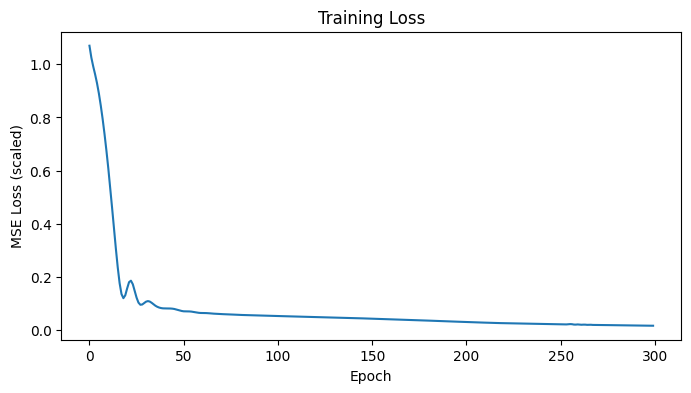

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (scaled)")
plt.title("Training Loss")
plt.show()

In [13]:
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_t).numpy()

# Inverse transform back to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = y_test  # already in original scale

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

MSE:  2.0465
RMSE: 1.4306
R2:   0.9338


In [14]:
# Example: TV=150, Radio=25, Newspaper=20
sample = np.array([[150, 25, 20]])
sample_scaled = scaler_X.transform(sample)
sample_t = torch.tensor(sample_scaled, dtype=torch.float32)

model.eval()
with torch.no_grad():
    pred_scaled = model(sample_t).numpy()

pred_sales = scaler_y.inverse_transform(pred_scaled)
print(f"Predicted Sales: {pred_sales[0][0]:.2f}")

Predicted Sales: 15.26


In [15]:
comparison = pd.DataFrame({
    "Actual": y_true.flatten(),
    "Predicted": y_pred.flatten()
})
comparison["Error"] = comparison["Actual"] - comparison["Predicted"]
print(comparison.head(10))

   Actual  Predicted     Error
0    16.9  16.071297  0.828703
1    22.4  21.591114  0.808886
2    21.4  21.836126 -0.436126
3     7.3   6.585969  0.714031
4    24.7  24.111143  0.588857
5    12.6  12.250773  0.349227
6    22.3  22.396463 -0.096463
7     8.4   9.132005 -0.732005
8    16.5  17.067669 -0.567669
9    16.1  16.906944 -0.806944
